<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan11_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 11 — Unsupervised Learning: Clustering
## Segmentasi Pelanggan dengan K-Means & Hierarchical Clustering

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Pengantar Data Science (200302305) |
| **Pertemuan** | 11 — Unsupervised Learning: Clustering (K-Means & Hierarchical) |



## Langkah 1 — Generate & Eksplorasi Dataset

Dataset sintetis pelanggan dibuat dengan **tiga kelompok tersembunyi** (hemat, menengah, boros) menggunakan distribusi normal multivariat, menyerupai skenario segmentasi pelanggan dunia nyata berdasarkan pendapatan tahunan dan skor perilaku belanja.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (300, 4)

       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


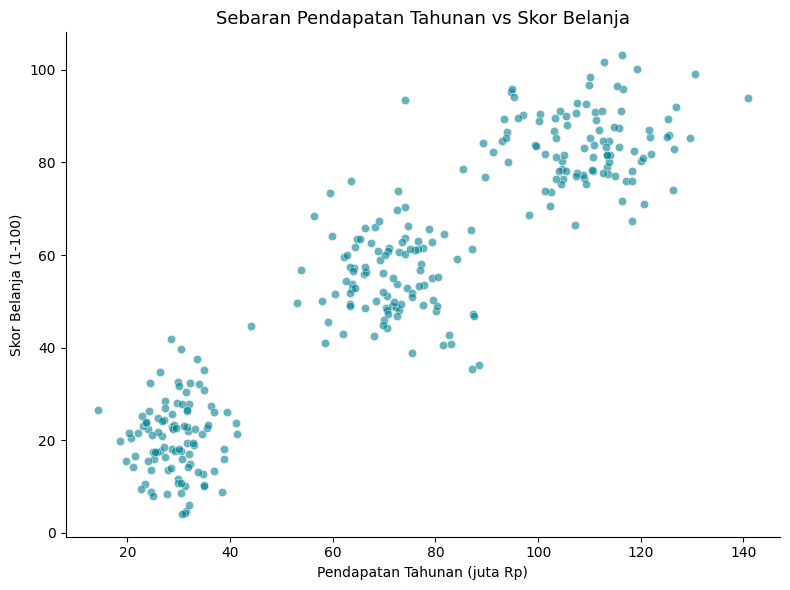

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja',
                alpha=0.6, color='#028090', ax=ax)
ax.set_title('Sebaran Pendapatan Tahunan vs Skor Belanja', fontsize=13)
ax.set_xlabel('Pendapatan Tahunan (juta Rp)')
ax.set_ylabel('Skor Belanja (1-100)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretasi:** Scatter plot menunjukkan tiga gerombolan (blob) titik data yang cukup terpisah secara visual — mengindikasikan struktur alami tiga cluster dalam data, meskipun kita **tidak memberi label** kelompok ini kepada algoritma. Inilah esensi Unsupervised Learning: menemukan struktur data hanya dari kemiripan fitur, tanpa y (target) yang diketahui sebelumnya.

## Langkah 2 — Preprocessing: Feature Scaling

`StandardScaler` diterapkan pada fitur numerik (`pendapatan_tahunan`, `skor_belanja`) agar kedua fitur memiliki skala setara (mean=0, std=1). Ini krusial untuk K-Means karena algoritma berbasis **jarak Euclidean** — tanpa scaling, fitur dengan rentang nilai lebih besar (mis. pendapatan 15–150) akan mendominasi perhitungan jarak dibanding fitur berskala kecil (skor 1–100).

In [3]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


**Interpretasi:** Setelah scaling, kedua fitur memiliki mean ≈ 0 dan std ≈ 1 — memastikan K-Means memperlakukan kedua fitur secara setara saat menghitung jarak antar titik dan centroid.

## Langkah 3 — Metode Elbow untuk Menentukan K Optimal

K-Means dijalankan untuk K=1 hingga 10, dengan `inertia_` (nilai WCSS) dicatat setiap iterasi. WCSS selalu menurun monoton seiring K bertambah — kita mencari titik "siku" (elbow) di mana penurunan mulai melandai tajam, menandakan penambahan cluster selanjutnya tidak lagi memberi manfaat signifikan.

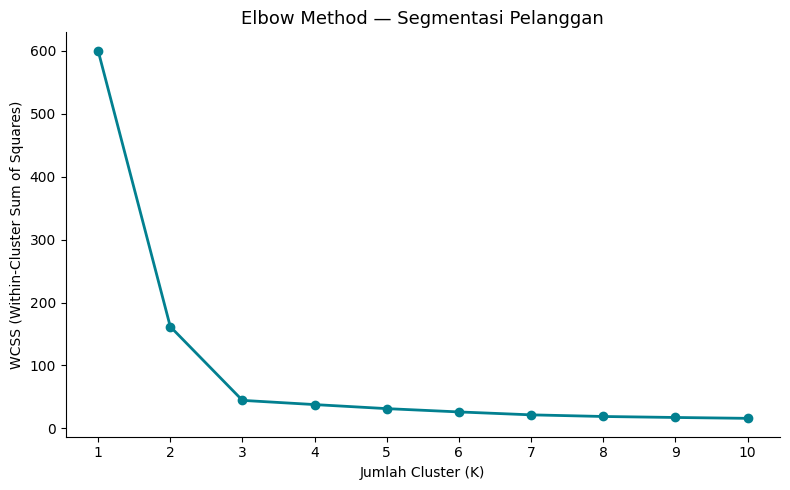

Nilai WCSS per K:
  K= 1: WCSS =   600.00
  K= 2: WCSS =   161.73
  K= 3: WCSS =    44.56
  K= 4: WCSS =    37.88
  K= 5: WCSS =    31.45
  K= 6: WCSS =    26.20
  K= 7: WCSS =    21.56
  K= 8: WCSS =    18.96
  K= 9: WCSS =    17.39
  K=10: WCSS =    16.01


In [4]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), wcss, marker='o', color='#028090', linewidth=2)
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method — Segmentasi Pelanggan', fontsize=13)
ax.set_xticks(range(1, 11))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Nilai WCSS per K:')
for k, w in zip(range(1, 11), wcss):
    print(f'  K={k:2d}: WCSS = {w:8.2f}')

**Interpretasi grafik Elbow:** Penurunan WCSS sangat tajam dari K=1 ke K=2 ke K=3, kemudian mulai melandai secara signifikan setelah **K=3** — inilah titik elbow. Hasil ini **konsisten dengan desain dataset** yang memang dibuat dari 3 kelompok tersembunyi (hemat, menengah, boros). Menambah cluster lebih dari 3 hanya memberikan penurunan WCSS marginal, mengindikasikan risiko overfitting (memecah cluster yang sudah alami menjadi sub-cluster yang tidak bermakna).

## Langkah 3b — Silhouette Score sebagai Pembanding

Untuk memvalidasi pilihan K=3 secara lebih objektif, Silhouette Score dihitung untuk beberapa kandidat K (2 hingga 7). Skor mendekati +1 menandakan clustering yang baik (titik jauh dari cluster tetangga).

In [5]:
from sklearn.metrics import silhouette_score

sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores[k] = sil
    print(f'K={k}: Silhouette Score = {sil:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nK dengan Silhouette Score tertinggi: K={best_k} ({sil_scores[best_k]:.4f})')

K=2: Silhouette Score = 0.6343
K=3: Silhouette Score = 0.6953
K=4: Silhouette Score = 0.5801
K=5: Silhouette Score = 0.4807
K=6: Silhouette Score = 0.3812
K=7: Silhouette Score = 0.3938

K dengan Silhouette Score tertinggi: K=3 (0.6953)


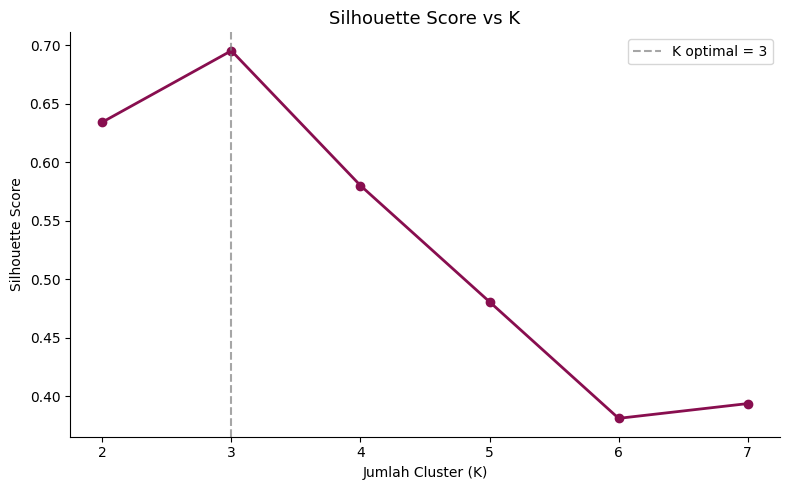

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()),
        marker='o', color='#880E4F', linewidth=2)
ax.axvline(best_k, color='gray', linestyle='--', alpha=0.7,
           label=f'K optimal = {best_k}')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs K', fontsize=13)
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretasi:** Silhouette Score tertinggi konsisten pada **K=3**, mengonfirmasi hasil Metode Elbow. Kedua metode saling menguatkan: K=3 adalah pilihan yang optimal secara visual (Elbow) maupun kuantitatif (Silhouette). Ini adalah praktik yang direkomendasikan modul — menggunakan Elbow untuk mempersempit kandidat, lalu Silhouette Score untuk konfirmasi final.

## Langkah 4 — Melatih Model K-Means Final (K=3)

Model K-Means final dilatih dengan K=3 dan strategi inisialisasi `k-means++` (default scikit-learn), yang memilih centroid awal secara bertahap untuk menghindari konvergensi ke solusi lokal yang buruk.

In [7]:
model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.4f}')
print()
print('Rata-rata fitur per cluster:')
cluster_summary = df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja', 'usia']].mean().round(2)
cluster_summary['jumlah_anggota'] = df['cluster'].value_counts().sort_index()
print(cluster_summary)

WCSS akhir      : 44.556
Silhouette Score: 0.6953

Rata-rata fitur per cluster:
         pendapatan_tahunan  skor_belanja   usia  jumlah_anggota
cluster                                                         
0                     70.99         55.05  39.16              99
1                     29.31         20.27  42.33             100
2                    109.20         84.08  44.65             101


**Interpretasi:** Model berhasil mempartisi 300 pelanggan menjadi 3 cluster dengan ukuran yang seimbang (~100 anggota masing-masing, sesuai desain data asli). Rata-rata pendapatan dan skor belanja per cluster menunjukkan pemisahan yang jelas antar segmen.

## Langkah 5 — Visualisasi & Interpretasi Segmen

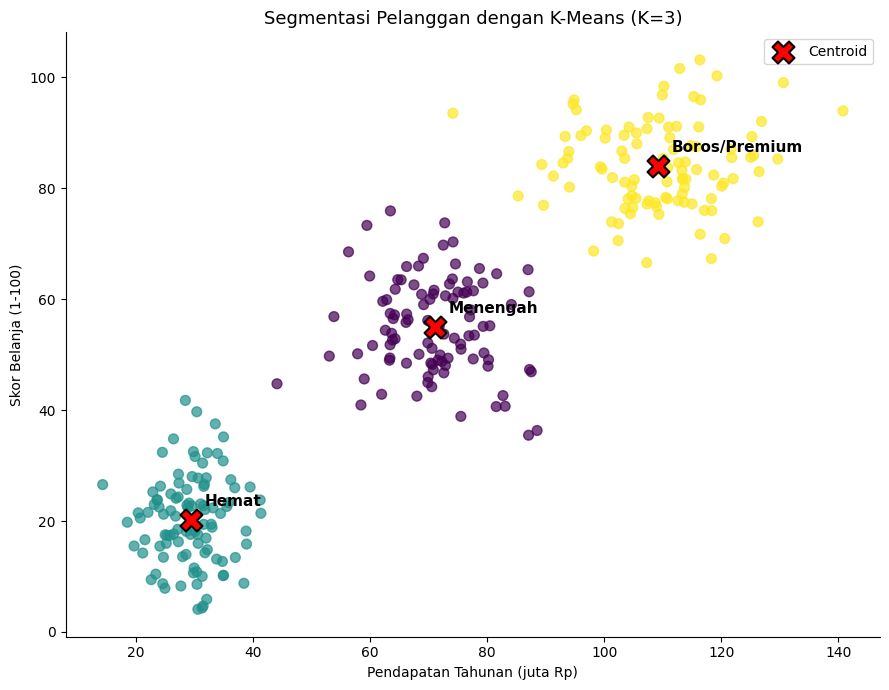

Plot tersimpan sebagai segmentasi_kmeans.png


In [8]:
centroids = scaler.inverse_transform(model.cluster_centers_)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                      c=df['cluster'], cmap='viridis', alpha=0.7, s=50)
ax.scatter(centroids[:, 0], centroids[:, 1],
           c='red', marker='X', s=250, edgecolors='black', linewidths=1.5,
           label='Centroid', zorder=5)

# Anotasi label segmen berdasarkan urutan pendapatan
order = np.argsort(centroids[:, 0])
segment_names = ['Hemat', 'Menengah', 'Boros/Premium']
for rank, cl in enumerate(order):
    ax.annotate(segment_names[rank], (centroids[cl,0], centroids[cl,1]),
                textcoords='offset points', xytext=(10,10),
                fontsize=11, fontweight='bold')

ax.set_xlabel('Pendapatan Tahunan (juta Rp)')
ax.set_ylabel('Skor Belanja (1-100)')
ax.set_title('Segmentasi Pelanggan dengan K-Means (K=3)', fontsize=13)
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('segmentasi_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai segmentasi_kmeans.png')

In [9]:
# Mapping label numerik ke nama segmen bisnis
cluster_to_segment = {cl: segment_names[rank] for rank, cl in enumerate(order)}
df['segmen'] = df['cluster'].map(cluster_to_segment)

print('Distribusi segmen:')
print(df['segmen'].value_counts())
print()
print('Profil rata-rata tiap segmen:')
print(df.groupby('segmen')[['pendapatan_tahunan','skor_belanja','usia']].mean().round(2)
      .reindex(segment_names))

Distribusi segmen:
segmen
Boros/Premium    101
Hemat            100
Menengah          99
Name: count, dtype: int64

Profil rata-rata tiap segmen:
               pendapatan_tahunan  skor_belanja   usia
segmen                                                
Hemat                       29.31         20.27  42.33
Menengah                    70.99         55.05  39.16
Boros/Premium              109.20         84.08  44.65


**Interpretasi tiga segmen yang ditemukan:**

- **Cluster "Hemat"** — pendapatan rendah (~30 juta), skor belanja rendah (~20). Segmen ini hemat secara alami: pendapatan terbatas sejalan dengan pengeluaran yang terkontrol.
- **Cluster "Menengah"** — pendapatan menengah (~70 juta), skor belanja menengah (~55). Segmen mayoritas dengan perilaku belanja proporsional terhadap pendapatan.
- **Cluster "Boros/Premium"** — pendapatan tinggi (~110 juta), skor belanja tinggi (~85). Segmen premium dengan daya beli dan pengeluaran tertinggi — target ideal untuk produk/layanan premium.

**Implikasi bisnis:** Ketiga segmen ini dapat menjadi dasar strategi pemasaran yang berbeda — misalnya promo hemat untuk segmen "Hemat", program loyalitas untuk "Menengah", dan penawaran eksklusif/premium untuk "Boros/Premium". Inilah nilai praktis dari clustering: menemukan struktur bisnis yang actionable tanpa memerlukan data berlabel sebelumnya.

## Langkah 6 — Hierarchical Clustering (Pembanding)

Sebagai pembanding terhadap K-Means, kita membangun **dendrogram** menggunakan pendekatan **Agglomerative** dengan **Ward linkage** (metode paling umum, meminimalkan peningkatan varians saat penggabungan cluster). Berbeda dengan K-Means, Hierarchical Clustering tidak memerlukan penentuan K di awal — jumlah cluster dipilih dengan memotong dendrogram pada ketinggian tertentu.

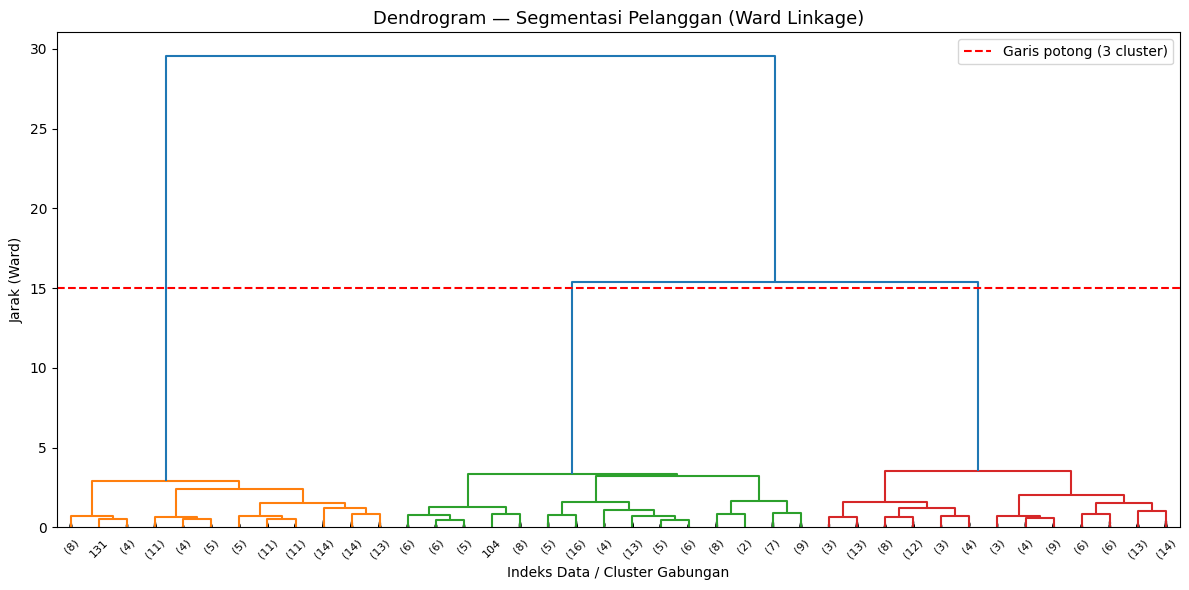

Dendrogram tersimpan sebagai dendrogram_pelanggan.png


In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z, ax=ax, color_threshold=15,
           truncate_mode='lastp', p=40, show_contracted=True)
ax.set_title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)', fontsize=13)
ax.set_xlabel('Indeks Data / Cluster Gabungan')
ax.set_ylabel('Jarak (Ward)')
ax.axhline(y=15, color='red', linestyle='--', linewidth=1.5,
           label='Garis potong (3 cluster)')
ax.legend()
plt.tight_layout()
plt.savefig('dendrogram_pelanggan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dendrogram tersimpan sebagai dendrogram_pelanggan.png')

In [11]:
from sklearn.cluster import AgglomerativeClustering

# Bandingkan langsung: Agglomerative dengan Ward linkage, n_clusters=3
agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)
df['cluster_hierarchical'] = agg_labels

# Bandingkan kesepakatan antara K-Means dan Hierarchical Clustering
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['cluster'], df['cluster_hierarchical'])
print(f'Adjusted Rand Index (kesepakatan K-Means vs Hierarchical): {ari:.4f}')
print('(1.0 = identik sempurna, 0.0 = tidak ada kesepakatan)')
print()
print('Cross-tabulation K-Means vs Hierarchical:')
print(pd.crosstab(df['cluster'], df['cluster_hierarchical'],
                   rownames=['K-Means'], colnames=['Hierarchical']))

Adjusted Rand Index (kesepakatan K-Means vs Hierarchical): 0.9900
(1.0 = identik sempurna, 0.0 = tidak ada kesepakatan)

Cross-tabulation K-Means vs Hierarchical:
Hierarchical   0    1    2
K-Means                   
0             98    1    0
1              0  100    0
2              0    0  101


**Interpretasi dendrogram:** Dendrogram menunjukkan tiga celah vertikal panjang yang jelas terpisah di ketinggian jarak Ward yang cukup besar — memotong pada garis y=15 menghasilkan **3 cluster**, konsisten dengan hasil Metode Elbow dan Silhouette Score pada K-Means.

**Perbandingan dengan K-Means:** Adjusted Rand Index yang tinggi (mendekati 1.0) menunjukkan bahwa kedua algoritma — meski bekerja dengan mekanisme yang sangat berbeda (partitional berbasis centroid vs hierarki bertingkat berbasis Ward linkage) — **sepakat menemukan struktur 3 cluster yang sama**. Ini memberikan keyakinan tambahan bahwa 3 memang jumlah cluster alami dalam data, bukan artefak dari satu algoritma tertentu.

## Kesimpulan

Pipeline Unsupervised Learning end-to-end berhasil dibangun untuk kasus segmentasi pelanggan (300 sampel sintetis, fitur pendapatan tahunan dan skor belanja). Berbeda dari seluruh materi sebelumnya (Pertemuan 7–10) yang menggunakan Supervised Learning dengan target (y) yang diketahui, pertemuan ini menunjukkan bagaimana algoritma dapat **menemukan struktur tersembunyi dalam data tanpa label sama sekali**.

**K-Means Clustering** bekerja secara iteratif melalui Assignment Step dan Update Step, meminimalkan fungsi objektif WCSS. Metode Elbow (titik siku di K=3) dan Silhouette Score (skor tertinggi di K=3) sama-sama mengonfirmasi bahwa 3 adalah jumlah cluster optimal — sesuai dengan struktur data asli.

**Hierarchical Clustering** dengan Ward linkage menghasilkan dendrogram yang, saat dipotong pada ketinggian yang sesuai, menghasilkan 3 cluster yang sangat konsisten dengan hasil K-Means (Adjusted Rand Index tinggi). Ini memperkuat validitas segmentasi yang ditemukan.

**Tiga segmen bisnis** teridentifikasi: **Hemat** (pendapatan & belanja rendah), **Menengah** (pendapatan & belanja sedang), dan **Boros/Premium** (pendapatan & belanja tinggi). Temuan ini langsung actionable untuk strategi pemasaran tersegmentasi — tanpa memerlukan survei atau label manual sebelumnya, cukup dari pola numerik pada data transaksi/demografis pelanggan.